# Exploración de Datos — Predicción del Precio de Vivienda
**Problema de Regresión: Valor de la Vivienda**  
Grupo 4 — Modelos Estadísticos

## 0. Instalación e importación de librerías

In [3]:
paquetes <- c("tidyverse", "ggplot2", "corrplot", "moments",
              "gridExtra", "scales", "knitr", "reshape2", "GGally")

nuevos <- paquetes[!(paquetes %in% installed.packages()[, "Package"])]
if (length(nuevos) > 0) install.packages(nuevos, quiet = TRUE)

# Cargar librerías
library(tidyverse)
library(ggplot2)
library(corrplot)
library(moments)    # skewness y kurtosis
library(gridExtra)
library(scales)
library(knitr)
library(reshape2)
library(GGally)

# Opciones globales
options(scipen = 999, digits = 3)
cat("✅ Librerías cargadas correctamente\n")

also installing the dependencies 'sys', 'bit', 'ps', 'sass', 'cachem', 'rappdirs', 'rematch', 'askpass', 'bit64', 'otel', 'processx', 'bslib', 'fontawesome', 'jquerylib', 'tinytex', 'backports', 'generics', 'memoise', 'blob', 'DBI', 'tidyselect', 'data.table', 'gargle', 'cellranger', 'curl', 'ids', 'rematch2', 'cpp11', 'pkgconfig', 'mime', 'openssl', 'timechange', 'systemfonts', 'textshaping', 'clipr', 'vroom', 'tzdb', 'callr', 'fs', 'rmarkdown', 'selectr', 'stringi', 'patchwork', 'prettyunits', 'broom', 'conflicted', 'dbplyr', 'dplyr', 'dtplyr', 'forcats', 'googledrive', 'googlesheets4', 'haven', 'hms', 'httr', 'lubridate', 'magrittr', 'modelr', 'purrr', 'ragg', 'readr', 'readxl', 'reprex', 'rstudioapi', 'rvest', 'stringr', 'tibble', 'tidyr', 'xml2', 'gtable', 'isoband', 'S7', 'withr', 'farver', 'labeling', 'R6', 'RColorBrewer', 'viridisLite', 'highr', 'xfun', 'yaml', 'plyr', 'Rcpp', 'ggstats', 'progress'




package 'sys' successfully unpacked and MD5 sums checked
package 'bit' successfully unpacked and MD5 sums checked
package 'ps' successfully unpacked and MD5 sums checked
package 'sass' successfully unpacked and MD5 sums checked
package 'cachem' successfully unpacked and MD5 sums checked
package 'rappdirs' successfully unpacked and MD5 sums checked
package 'rematch' successfully unpacked and MD5 sums checked
package 'askpass' successfully unpacked and MD5 sums checked
package 'bit64' successfully unpacked and MD5 sums checked
package 'otel' successfully unpacked and MD5 sums checked
package 'processx' successfully unpacked and MD5 sums checked
package 'bslib' successfully unpacked and MD5 sums checked
package 'fontawesome' successfully unpacked and MD5 sums checked
package 'jquerylib' successfully unpacked and MD5 sums checked
package 'tinytex' successfully unpacked and MD5 sums checked
package 'backports' successfully unpacked and MD5 sums checked
package 'generics' successfully unpack

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded


Adjuntando el paquete: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine



Adjuntando el paquete: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor



Adjuntando el paquete: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




✅ Librerías cargadas correctamente


## 1. Exploración inicial y estructura de datos

In [11]:
# Carga directa
df <- read.csv("Train real state.csv", stringsAsFactors = TRUE)

# Eliminar columna índice si existe
df$X <- NULL

cat("Dimensiones del dataset:", nrow(df), "filas x", ncol(df), "columnas\n")
head(df)

Dimensiones del dataset: 4124 filas x 30 columnas


,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.,N_SchoolNearBy.High.,N_SchoolNearBy.University.,N_FacilitiesInApt,N_FacilitiesNearBy.Total.,N_SchoolNearBy.Total.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,141592,2006,2007,8,814,3,terraced,individual_heating,management_in_trust,111,⋯,1,1,0,3,2,2,2,5,6,9
2,51327,1985,2007,8,587,8,corridor,individual_heating,self_management,80,⋯,1,2,1,2,1,1,0,3,12,4
3,48672,1985,2007,8,587,6,corridor,individual_heating,self_management,80,⋯,1,2,1,2,1,1,0,3,12,4
4,221238,1993,2007,8,1761,3,mixed,individual_heating,management_in_trust,523,⋯,1,5,0,4,3,5,5,4,14,17
5,78318,1992,2007,8,644,2,mixed,individual_heating,self_management,142,⋯,1,1,0,3,3,4,4,3,9,14
6,61946,1993,2007,8,644,10,mixed,individual_heating,management_in_trust,523,⋯,1,5,0,4,3,5,5,4,14,17


In [12]:
# Tipos de datos y estructura general
cat("=== ESTRUCTURA DEL DATASET ===\n")
str(df)

=== ESTRUCTURA DEL DATASET ===
'data.frame':	4124 obs. of  30 variables:
 $ SalePrice                         : int  141592 51327 48672 221238 78318 61946 83185 168141 153982 200884 ...
 $ YearBuilt                         : int  2006 1985 1985 1993 1992 1993 1992 1986 1986 2007 ...
 $ YrSold                            : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...
 $ MonthSold                         : int  8 8 8 8 8 8 8 8 8 8 ...
 $ Size.sqf.                         : int  814 587 587 1761 644 644 644 1377 914 868 ...
 $ Floor                             : int  3 8 6 3 2 10 13 4 11 18 ...
 $ HallwayType                       : Factor w/ 3 levels "corridor","mixed",..: 3 1 1 2 2 2 2 3 3 3 ...
 $ HeatingType                       : Factor w/ 2 levels "central_heating",..: 2 2 2 2 2 2 2 1 1 2 ...
 $ AptManageType                     : Factor w/ 2 levels "management_in_trust",..: 1 2 2 1 2 1 2 1 1 1 ...
 $ N_Parkinglot.Ground.              : int  111 80 80 523 142 523 142 7

In [13]:
# Identificar columnas categóricas y numéricas
cat_cols <- names(df)[sapply(df, is.factor)]
num_cols <- names(df)[sapply(df, is.numeric)]

# Remover el índice ('Unnamed..0' o 'X') y la variable objetivo para no tratarla como un predictor
num_cols_feat <- num_cols[!num_cols %in% c("SalePrice")]

cat("\nVariables categóricas (", length(cat_cols), "):\n")
print(cat_cols)

cat("\nVariables numéricas sin target (", length(num_cols_feat), "):\n")
print(num_cols_feat)


Variables categóricas ( 6 ):
[1] "HallwayType"   "HeatingType"   "AptManageType" "TimeToBusStop"
[5] "TimeToSubway"  "SubwayStation"

Variables numéricas sin target ( 23 ):
 [1] "YearBuilt"                          "YrSold"                            
 [3] "MonthSold"                          "Size.sqf."                         
 [5] "Floor"                              "N_Parkinglot.Ground."              
 [7] "N_Parkinglot.Basement."             "N_APT"                             
 [9] "N_manager"                          "N_elevators"                       
[11] "N_FacilitiesNearBy.PublicOffice."   "N_FacilitiesNearBy.Hospital."      
[13] "N_FacilitiesNearBy.Dpartmentstore." "N_FacilitiesNearBy.Mall."          
[15] "N_FacilitiesNearBy.ETC."            "N_FacilitiesNearBy.Park."          
[17] "N_SchoolNearBy.Elementary."         "N_SchoolNearBy.Middle."            
[19] "N_SchoolNearBy.High."               "N_SchoolNearBy.University."        
[21] "N_FacilitiesInApt"            

## 2. Calidad y Limpieza de datos

In [16]:
# === Valores faltantes y duplicados ===
missing_df <- data.frame(
  Variable    = names(df),
  Faltantes   = colSums(is.na(df)),
  Porcentaje  = round(colSums(is.na(df)) / nrow(df) * 100, 2)
)

missing_df <- missing_df[missing_df$Faltantes > 0, ]
missing_df <- missing_df[order(-missing_df$Porcentaje), ]

if (nrow(missing_df) == 0) {
  cat("No hay valores faltantes en el dataset\n")
} else {
  print(missing_df)
}

# === DUPLICADOS ===
n_dup <- sum(duplicated(df))
cat("Filas duplicadas exactas:", n_dup, "\n")

No hay valores faltantes en el dataset
Filas duplicadas exactas: 192 


In [17]:
# Ver los grupos de duplicados, ordenados para comparar pares
dup_view <- df[duplicated(df) | duplicated(df, fromLast = TRUE), ]
dup_view <- dup_view[order(dup_view$SalePrice, dup_view$Size.sqf., dup_view$Floor), ]
head(dup_view[, c("SalePrice","YearBuilt","Size.sqf.","Floor","SubwayStation")], 20)

,SalePrice,YearBuilt,Size.sqf.,Floor,SubwayStation
,<int>,<int>,<int>,<int>,<fct>
719,61946,1992,576,11,Myung-duk
724,61946,1992,576,11,Myung-duk
873,73053,2005,572,6,Bangoge
926,73053,2005,572,6,Bangoge
938,73442,2005,572,9,Bangoge
944,73442,2005,572,9,Bangoge
856,73840,2005,572,11,Bangoge
908,73840,2005,572,11,Bangoge
842,73840,2005,572,12,Bangoge


In [18]:
# Eliminar duplicados exactos
df <- df[!duplicated(df), ]

cat("Dimensiones tras eliminar duplicados:", nrow(df), "filas x", ncol(df), "columnas\n")

Dimensiones tras eliminar duplicados: 3932 filas x 30 columnas


## 3. Estadísticas descriptivas, distribución y outliers - Variables numericas

In [ ]:
# Estadisticas descriptivas para variables numéricas
vars_num <- df[, c(num_cols_feat, "SalePrice")]

tabla_desc <- data.frame(
  COLUMNA = names(vars_num),
  CONTEO  = sapply(vars_num, function(x) sum(!is.na(x))),
  MEDIA   = round(sapply(vars_num, mean,   na.rm = TRUE), 2),
  MEDIANA = round(sapply(vars_num, median, na.rm = TRUE), 2),
  STD     = round(sapply(vars_num, sd,     na.rm = TRUE), 2),
  MIN     = sapply(vars_num, min, na.rm = TRUE),
  Q25     = sapply(vars_num, quantile, probs = 0.25, na.rm = TRUE),
  Q50     = sapply(vars_num, quantile, probs = 0.50, na.rm = TRUE),
  Q75     = sapply(vars_num, quantile, probs = 0.75, na.rm = TRUE),
  MAX     = sapply(vars_num, max, na.rm = TRUE),
  stringsAsFactors = FALSE
)
rownames(tabla_desc) <- NULL

# Mostrar en el notebook
library(knitr)
kable(tabla_desc, col.names = c("COLUMNA","CONTEO","MEDIA","MEDIANA","STD",
                                "MIN","25%","50%","75%","MAX"))



|COLUMNA                            | CONTEO|     MEDIA| MEDIANA|       STD|   MIN|    25%|    50%|    75%|    MAX|
|:----------------------------------|------:|---------:|-------:|---------:|-----:|------:|------:|------:|------:|
|YearBuilt                          |   3932|   2002.65|    2006|      8.89|  1978|   1993|   2006|   2007|   2015|
|YrSold                             |   3932|   2012.68|    2013|      2.89|  2007|   2010|   2013|   2015|   2017|
|MonthSold                          |   3932|      6.30|       6|      3.35|     1|      3|      6|      9|     12|
|Size.sqf.                          |   3932|    969.61|     910|    377.88|   135|    644|    910|   1160|   2337|
|Floor                              |   3932|     12.15|      11|      7.69|     1|      6|     11|     17|     43|
|N_Parkinglot.Ground.               |   3932|    201.48|     111|    219.85|     0|     25|    111|    249|    713|
|N_Parkinglot.Basement.             |   3932|    559.41|     536|    4

No id variables; using all as measure variables



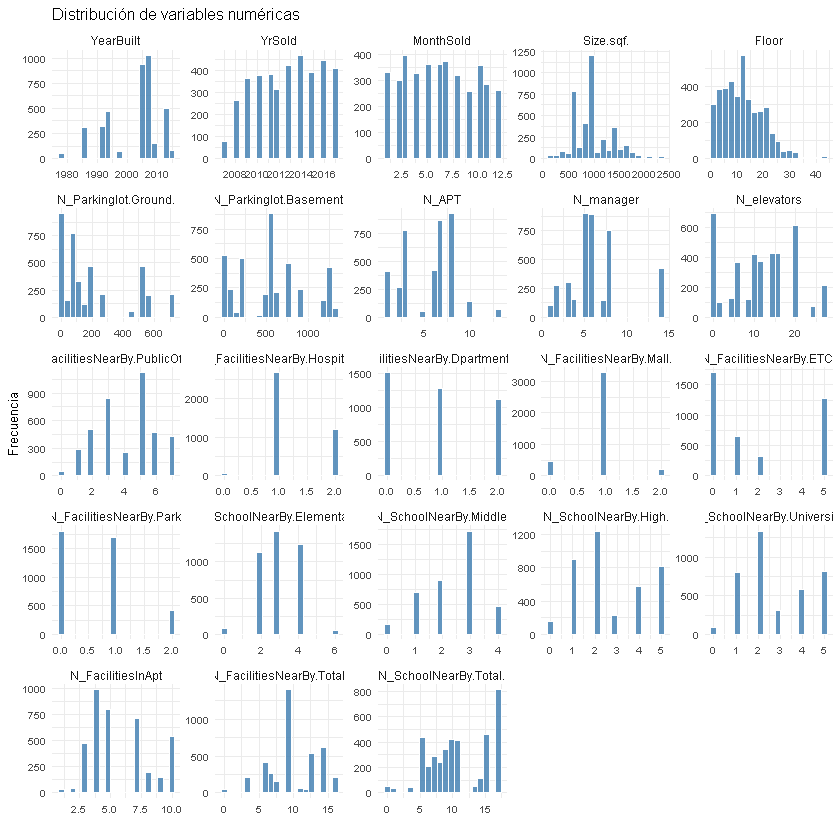

In [ ]:
# Distribución de variables numéricas 
library(ggplot2)
library(reshape2)

# Convertir a formato largo para graficar todas juntas
df_long <- melt(df[, num_cols_feat])

ggplot(df_long, aes(x = value)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white", alpha = 0.85) +
  facet_wrap(~ variable, scales = "free", ncol = 5) +
  theme_minimal(base_size = 8) +
  labs(title = "Distribución de variables numéricas", x = "", y = "Frecuencia") +
  theme(strip.text = element_text(size = 7),
        axis.text = element_text(size = 6))
ggsave("distribucion_numericas.png", width = 14, height = 12, dpi = 150)

No id variables; using all as measure variables



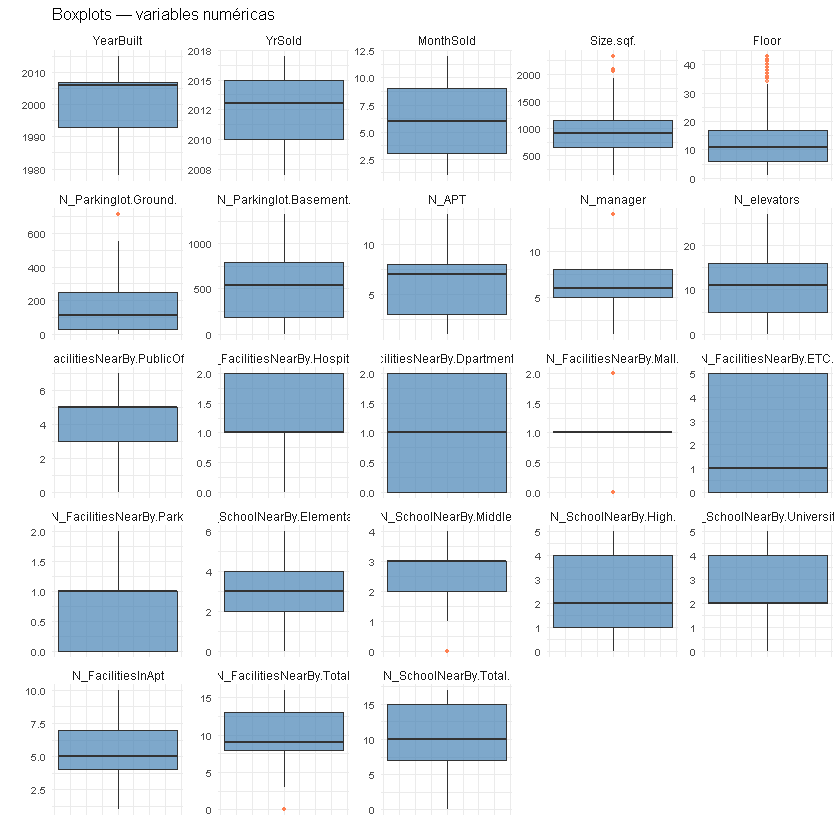

In [29]:
# Boxplots para detectar outliers
library(ggplot2)
library(reshape2)

df_long <- melt(df[, num_cols_feat])

ggplot(df_long, aes(y = value)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7,
               outlier.color = "coral", outlier.size = 0.8) +
  facet_wrap(~ variable, scales = "free", ncol = 5) +
  theme_minimal(base_size = 8) +
  labs(title = "Boxplots — variables numéricas", x = "", y = "") +
  theme(strip.text = element_text(size = 7),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(size = 6))
ggsave("boxplots_numericas.png", width = 14, height = 12, dpi = 150)

## 4. Estadísticas descriptivas y frecuencia - Variables categoricas

In [ ]:
# Estadísticas descriptivas para variables categóricas
tabla_cat <- data.frame(
  COLUMNA    = cat_cols,
  CONTEO     = sapply(cat_cols, function(c) sum(!is.na(df[[c]]))),
  CATEGORIAS = sapply(cat_cols, function(c) nlevels(df[[c]])),
  TOP        = sapply(cat_cols, function(c) names(which.max(table(df[[c]])))),
  FRECUENCIA = sapply(cat_cols, function(c) max(table(df[[c]]))),
  PORCENTAJE = sapply(cat_cols, function(c) round(max(table(df[[c]])) / sum(!is.na(df[[c]])) * 100, 2))
)
rownames(tabla_cat) <- NULL

library(knitr)
kable(tabla_cat, align = "lrrlrr",
      col.names = c("COLUMNA","CONTEO","CATEGORÍAS","TOP","FRECUENCIA","% TOP"))

write.csv2(tabla_cat, "estadisticas_categoricas.csv", row.names = FALSE)




|COLUMNA       | CONTEO| CATEGORÍAS|TOP                   | FRECUENCIA| % TOP|
|:-------------|------:|----------:|:---------------------|----------:|-----:|
|HallwayType   |   3932|          3|terraced              |       2380|  60.5|
|HeatingType   |   3932|          2|individual_heating    |       3720|  94.6|
|AptManageType |   3932|          2|management_in_trust   |       3684|  93.7|
|TimeToBusStop |   3932|          3|0~5min                |       2977|  75.7|
|TimeToSubway  |   3932|          5|0-5min                |       1830|  46.5|
|SubwayStation |   3932|          8|Kyungbuk_uni_hospital |       1072|  27.3|

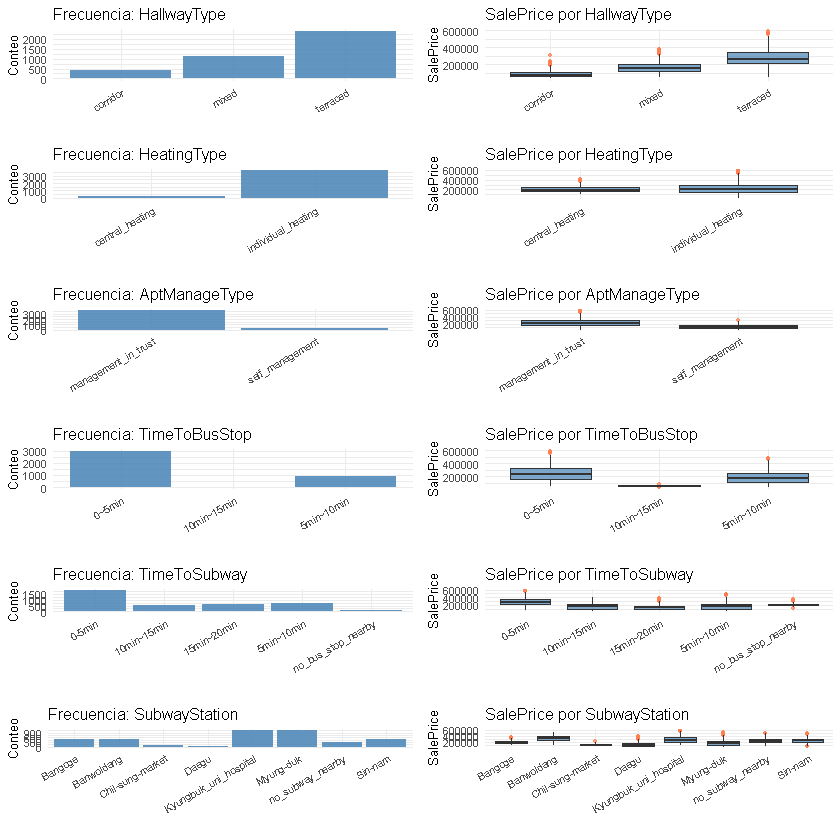

In [35]:
# Variables categóricas: frecuencia y boxplot de SalePrice
library(ggplot2)
library(gridExtra)

plots <- list()

for (col in cat_cols) {
  # Gráfico de frecuencia
  p1 <- ggplot(df, aes(x = .data[[col]])) +
    geom_bar(fill = "steelblue", alpha = 0.85) +
    theme_minimal(base_size = 8) +
    labs(title = paste("Frecuencia:", col), x = "", y = "Conteo") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 6))

  # Boxplot SalePrice por categoría
  p2 <- ggplot(df, aes(x = .data[[col]], y = SalePrice)) +
    geom_boxplot(fill = "steelblue", alpha = 0.7,
                 outlier.color = "coral", outlier.size = 0.8) +
    theme_minimal(base_size = 8) +
    labs(title = paste("SalePrice por", col), x = "", y = "SalePrice") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 6))

  plots[[length(plots) + 1]] <- p1
  plots[[length(plots) + 1]] <- p2
}

# Organizar en grilla (2 columnas: frecuencia + boxplot por fila)
grid.arrange(grobs = plots, ncol = 2)

g <- arrangeGrob(grobs = plots, ncol = 2)
ggsave("categoricas_frecuencia.png", g, width = 12, height = 18, dpi = 150)

## 5. Análisis de la variable objetivo: SalePrice

Media:     225857 
Mediana:   212389 
Skewness:  0.439 
Kurtosis:  2.68 


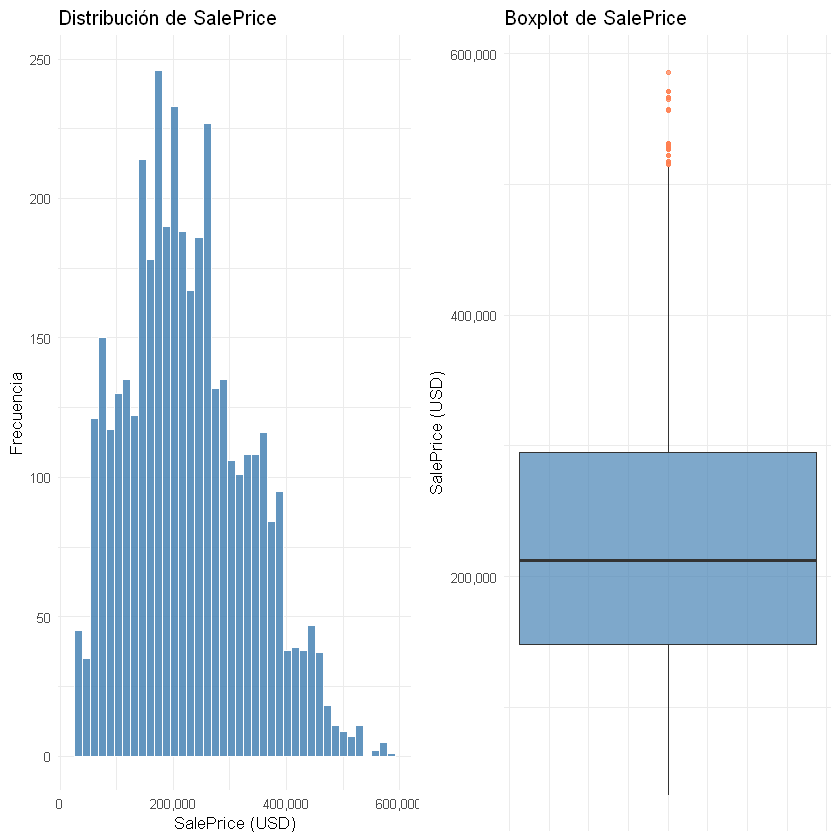

In [37]:
# === VARIABLE OBJETIVO: SALEPRICE ===
library(ggplot2)
library(gridExtra)
library(scales)

# Histograma
p1 <- ggplot(df, aes(x = SalePrice)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white", alpha = 0.85) +
  scale_x_continuous(labels = comma) +
  theme_minimal(base_size = 10) +
  labs(title = "Distribución de SalePrice", x = "SalePrice (USD)", y = "Frecuencia")

# Boxplot
p2 <- ggplot(df, aes(y = SalePrice)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7,
               outlier.color = "coral", outlier.size = 1) +
  scale_y_continuous(labels = comma) +
  theme_minimal(base_size = 10) +
  labs(title = "Boxplot de SalePrice", y = "SalePrice (USD)") +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

grid.arrange(p1, p2, ncol = 2)

# Estadísticas de forma
library(moments)
cat("Media:    ", round(mean(df$SalePrice), 2), "\n")
cat("Mediana:  ", round(median(df$SalePrice), 2), "\n")
cat("Skewness: ", round(skewness(df$SalePrice), 3), "\n")
cat("Kurtosis: ", round(kurtosis(df$SalePrice), 3), "\n")

g <- arrangeGrob(p1, p2, ncol = 2)
ggsave("variable_objetivo.png", g, width = 14, height = 5, dpi = 150)

## 6. Correlación entre variables numéricas

agg_record_3908398736c2 
                      2

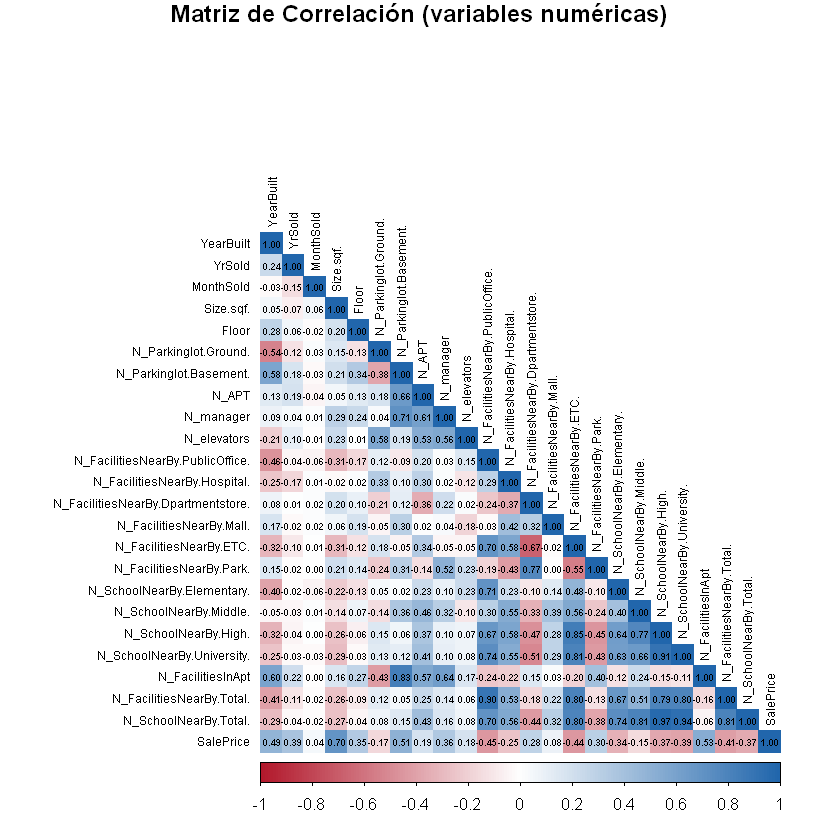

In [40]:
# === MATRIZ DE CORRELACIÓN (VARIABLES NUMÉRICAS) ===
library(corrplot)

# Calcular correlaciones (predictores + target)
corr_matrix <- cor(df[, c(num_cols_feat, "SalePrice")])

# Visualización
corrplot(corr_matrix, method = "color", type = "lower",
         tl.cex = 0.6, tl.col = "black",
         number.cex = 0.45, addCoef.col = "black",
         col = colorRampPalette(c("#B2182B", "white", "#2166AC"))(200),
         title = "Matriz de Correlación (variables numéricas)",
         mar = c(0,0,1,0))

png("matriz_correlacion.png", width = 1600, height = 1400, res = 130)
corrplot(corr_matrix, method = "color", type = "lower",
         tl.cex = 0.6, tl.col = "black",
         number.cex = 0.45, addCoef.col = "black",
         col = colorRampPalette(c("#B2182B", "white", "#2166AC"))(200),
         mar = c(0,0,1,0))
dev.off()

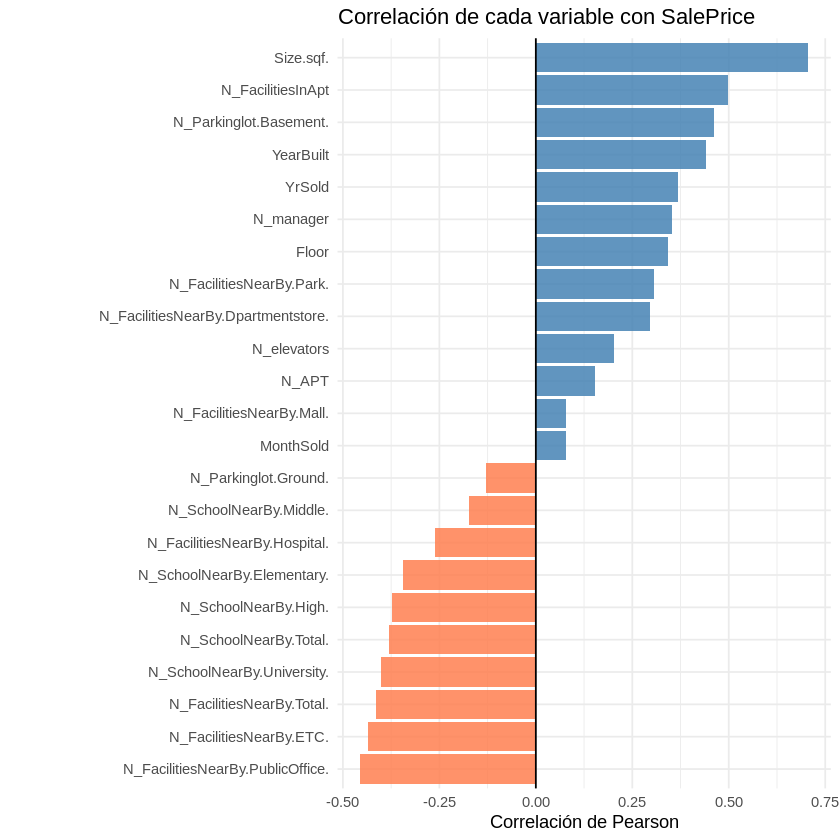

In [23]:
# Top correlaciones con SalePrice (ordenadas por valor absoluto)
corr_target <- corr_matrix["SalePrice", ]
corr_target <- corr_target[names(corr_target) != "SalePrice"]
corr_target <- sort(corr_target, decreasing = FALSE)  # ascendente para barh

corr_df <- data.frame(
  Variable    = names(corr_target),
  Correlacion = as.numeric(corr_target)
)
corr_df$Color <- ifelse(corr_df$Correlacion >= 0, "positiva", "negativa")

ggplot(corr_df, aes(x = Correlacion,
                    y = reorder(Variable, Correlacion),
                    fill = Color)) +
  geom_bar(stat = "identity", alpha = 0.85) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +
  scale_fill_manual(values = c("positiva" = "steelblue",
                               "negativa" = "coral")) +
  labs(title = "Correlación de cada variable con SalePrice",
       x = "Correlación de Pearson", y = "") +
  theme_minimal() +
  theme(legend.position = "none")

## 7. Scatter plots — variables más correlacionadas con SalePrice

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


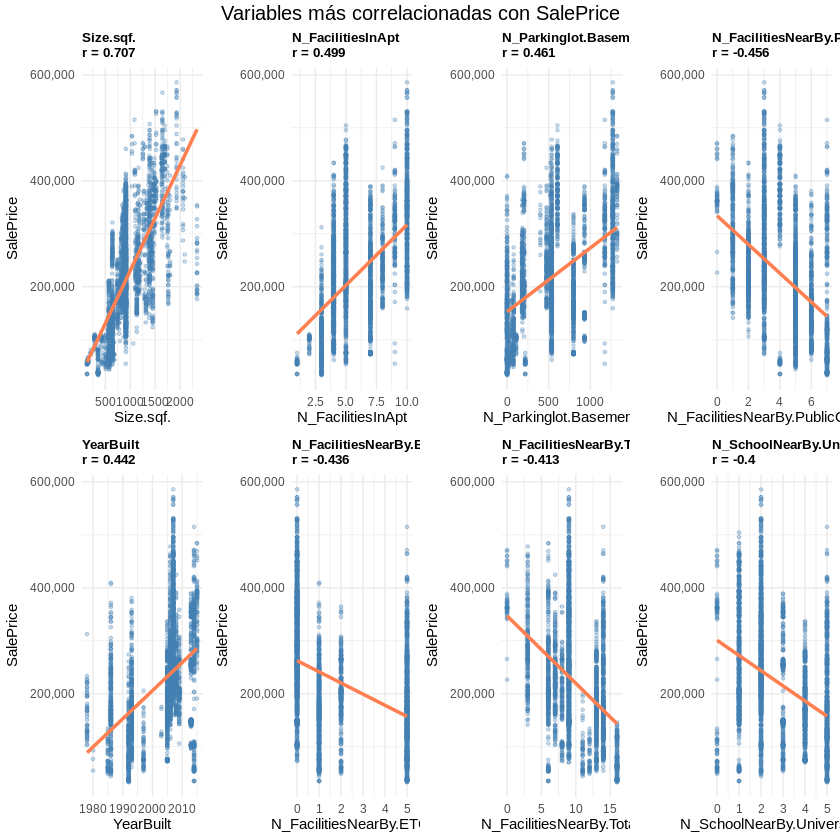

In [24]:
# Top 8 variables con mayor correlación absoluta
top8 <- names(sort(abs(corr_target), decreasing = TRUE))[1:8]

plots_scatter <- lapply(top8, function(col) {
  r_val <- round(cor(df[[col]], df$SalePrice, use = "complete.obs"), 3)
  ggplot(df, aes_string(x = col, y = "SalePrice")) +
    geom_point(alpha = 0.3, color = "steelblue", size = 0.8) +
    geom_smooth(method = "lm", se = FALSE, color = "coral", linewidth = 1) +
    scale_y_continuous(labels = comma) +
    labs(title = paste0(col, "\nr = ", r_val),
         x = col, y = "SalePrice") +
    theme_minimal(base_size = 9) +
    theme(plot.title = element_text(size = 8, face = "bold"))
})

do.call(grid.arrange, c(plots_scatter, ncol = 4,
  top = "Variables más correlacionadas con SalePrice"))

## 8. Resumen final de la exploración

In [25]:
cat(strrep("=", 60), "\n")
cat("         RESUMEN DE LA EXPLORACIÓN DE DATOS\n")
cat(strrep("=", 60), "\n")
cat(sprintf("  Observaciones:            %d\n",   nrow(df)))
cat(sprintf("  Variables totales:        %d\n",   ncol(df)))
cat(sprintf("  Variables numéricas:      %d\n",   length(num_cols_feat)))
cat(sprintf("  Variables categóricas:    %d\n",   length(cat_cols)))
cat(sprintf("  Columnas con nulos:       %d\n",   sum(colSums(is.na(df)) > 0)))
cat(sprintf("  SalePrice — Media:        $%s\n",  format(round(mean(df$SalePrice), 0), big.mark=",")))
cat(sprintf("  SalePrice — Mediana:      $%s\n",  format(median(df$SalePrice), big.mark=",")))
cat(sprintf("  SalePrice — Std:          $%s\n",  format(round(sd(df$SalePrice), 0), big.mark=",")))
cat(sprintf("  SalePrice — Min:          $%s\n",  format(min(df$SalePrice), big.mark=",")))
cat(sprintf("  SalePrice — Max:          $%s\n",  format(max(df$SalePrice), big.mark=",")))
cat(sprintf("  Asimetría SalePrice:      %.4f\n", skewness(df$SalePrice)))
cat("\n  Top 5 correlaciones con SalePrice:\n")
top5_corr <- sort(abs(corr_target), decreasing = TRUE)[1:5]
for (nm in names(top5_corr)) {
  cat(sprintf("    %-35s r = %.4f\n", nm, corr_matrix["SalePrice", nm]))
}
cat(strrep("=", 60), "\n")

         RESUMEN DE LA EXPLORACIÓN DE DATOS
  Observaciones:            4124
  Variables totales:        31
  Variables numéricas:      23
  Variables categóricas:    6
  Columnas con nulos:       0
  SalePrice — Media:        $221,688
  SalePrice — Mediana:      $207,964
  SalePrice — Std:          $106,353
  SalePrice — Min:          $32,743
  SalePrice — Max:          $585,840
  Asimetría SalePrice:      0.4800

  Top 5 correlaciones con SalePrice:
    Size.sqf.                           r = 0.7065
    N_FacilitiesInApt                   r = 0.4988
    N_Parkinglot.Basement.              r = 0.4611
    N_FacilitiesNearBy.PublicOffice.    r = -0.4558
    YearBuilt                           r = 0.4421
